In [1]:
!pip install -r requirements.txt --no-cache-dir

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.9/89.9 kB 398.5 kB/s eta 0:00:00a 0:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 487.4 kB/s eta 0:00:00a 0:00:01
Reason for being yanked: The Windows wheels, under some conditions, caused segfaults in unrelated user code.  Due to this we deleted the Windows wheels to prevent these segfaults, however this caused greater disruption as pip then began to try (and fail) to build 3.9.1 from the sdist on Windows which impacted far more users.  Yanking the whole release is the only tool available to eliminate these failures without changes to on the user side.  The sdist, OSX wheel, and manylinux wheels are all functional and there are no critical bugs in the release.   Downstream packagers should not yank their builds of Matplotlib 3.9.1.  See https://github.com/matplotlib/matplotlib/issues/28551 for details.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.1/13.1 MB 355.8 kB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import os

# Update this path to where you saved the sample CSV
DATA_PATH = './data/sample_security_logs.csv'

# Create dummy data if file is missing (so you can still test the logic)
if not os.path.exists(DATA_PATH):
    os.makedirs('./data', exist_ok=True)
    print("Generating sample security logs for the lab...")
    data = {
        'timestamp': pd.date_range(start='2026-03-12', periods=1000, freq='T'),
        'src_ip': ['192.168.1.' + str(i%10) for i in range(1000)],
        'dst_ip': ['10.0.0.' + str(i%5) for i in range(1000)],
        'dst_port': [80, 443, 22, 80, 443] * 200,
        'protocol': ['TCP', 'TCP', 'SSH', 'HTTP', 'HTTPS'] * 200,
        'event_type': ['login', 'flow', 'flow', 'login', 'flow'] * 200,
        'user': ['admin', 'user1', 'user2', 'admin', 'user1'] * 200
    }
    df_temp = pd.DataFrame(data)
    # Inject some anomalies (Unusual port and user)
    df_temp.loc[950:, 'dst_port'] = 9999
    df_temp.loc[950:, 'user'] = 'unknown_attacker'
    df_temp.to_csv(DATA_PATH, index=False)

try:
    df = pd.read_csv(DATA_PATH)
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    df.set_index('timestamp', inplace=True)
    print(f"✅ Loaded {len(df)} log entries.")
except Exception as e:
    print(f"❌ Error: {e}")

# Preprocessing Pipeline
categorical_features = ['src_ip', 'dst_ip', 'protocol', 'event_type', 'user']
numerical_features = ['dst_port']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

df_processed = preprocessor.fit_transform(df)
if hasattr(df_processed, 'toarray'):
    df_processed = df_processed.toarray()
print(f"✅ Data preprocessed. Shape: {df_processed.shape}")

Generating sample security logs for the lab...
✅ Loaded 1000 log entries.
✅ Data preprocessed. Shape: (1000, 26)


/tmp/ipykernel_6468/3440211608.py:18: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  'timestamp': pd.date_range(start='2026-03-12', periods=1000, freq='T'),


In [2]:
# Initialize and train the model
# contamination='auto' lets the AI estimate the number of outliers
model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)

print("🕵️ Training Isolation Forest...")
model.fit(df_processed)

# 1: Normal, -1: Anomaly
df['anomaly'] = model.predict(df_processed)
# Lower score = more anomalous
df['anomaly_score'] = model.decision_function(df_processed)

anomalous_events = df[df['anomaly'] == -1]
print(f"🚨 Found {len(anomalous_events)} potential anomalies.")
print(anomalous_events[['src_ip', 'dst_port', 'user', 'anomaly_score']].head())

🕵️ Training Isolation Forest...
🚨 Found 50 potential anomalies.
                          src_ip  dst_port              user  anomaly_score
timestamp                                                                  
2026-03-12 15:50:00  192.168.1.0      9999  unknown_attacker      -0.146792
2026-03-12 15:51:00  192.168.1.1      9999  unknown_attacker      -0.146691
2026-03-12 15:52:00  192.168.1.2      9999  unknown_attacker      -0.142121
2026-03-12 15:53:00  192.168.1.3      9999  unknown_attacker      -0.143244
2026-03-12 15:54:00  192.168.1.4      9999  unknown_attacker      -0.150863


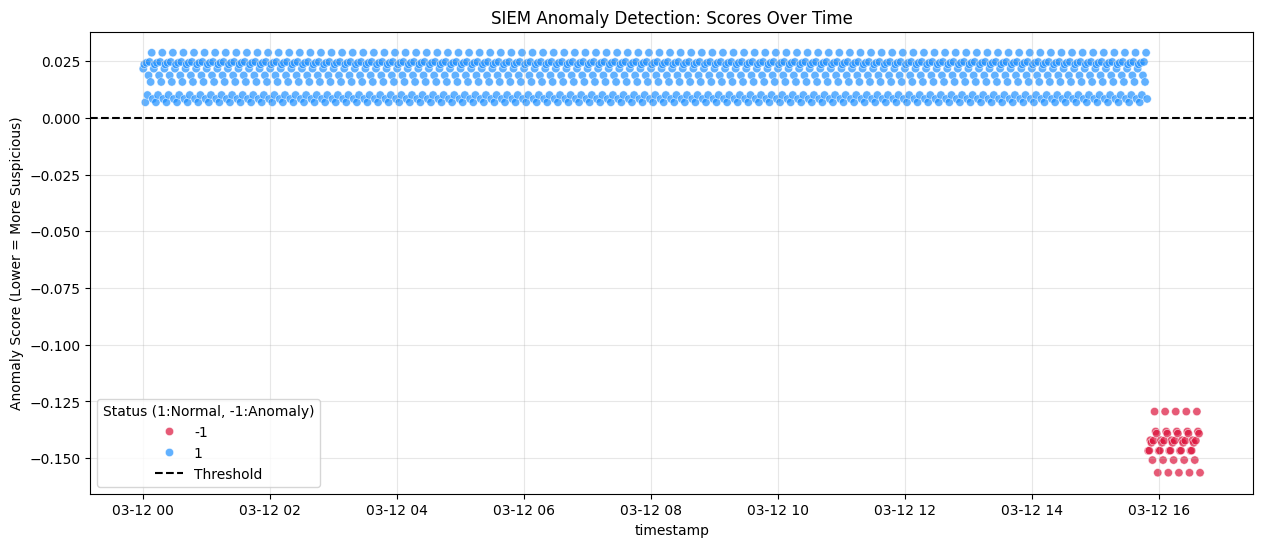

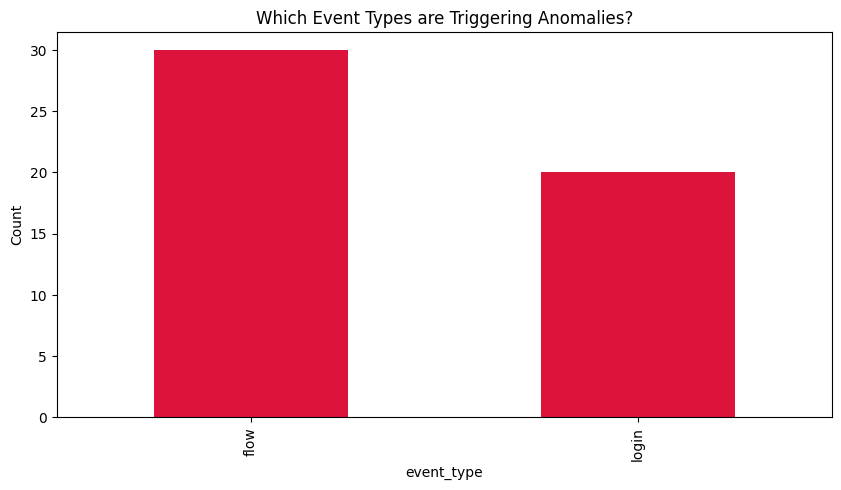

In [3]:
plt.figure(figsize=(15, 6))
# Plotting scores over time
sns.scatterplot(data=df, x=df.index, y='anomaly_score', hue='anomaly', 
                palette={1: 'dodgerblue', -1: 'crimson'}, alpha=0.7)

plt.axhline(y=0, color='black', linestyle='--', label='Threshold')
plt.title('SIEM Anomaly Detection: Scores Over Time')
plt.ylabel('Anomaly Score (Lower = More Suspicious)')
plt.legend(title='Status (1:Normal, -1:Anomaly)')
plt.grid(True, alpha=0.3)
plt.show()

# Distribution of Anomaly Types
if not anomalous_events.empty:
    plt.figure(figsize=(10, 5))
    anomalous_events['event_type'].value_counts().plot(kind='bar', color='crimson')
    plt.title('Which Event Types are Triggering Anomalies?')
    plt.ylabel('Count')
    plt.show()